## 1. GPU, Drive and code

In [1]:
!nvidia-smi

Fri Oct  9 18:24:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Our repository (main branch) and the baseline repository (read-only, git-ignored)
!git clone https://github.com/kashishfatima999/Confidence-Aware-Self-Prompting-for-Robust-Polyp-Segmentation.git /content/proj
%cd /content/proj
!git clone https://github.com/sajjad-sh33/YOLO_SAM2.git external/YOLO_SAM2

import os
if not os.path.exists("src/data/make_corruptions.py"):
    !git fetch -q origin project-divison
    !git checkout origin/project-divison -- src/data/make_corruptions.py
!git branch
!ls src/data

Mounted at /content/drive
Cloning into '/content/proj'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 139 (delta 42), reused 133 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (139/139), 715.82 KiB | 7.87 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/proj
Cloning into 'external/YOLO_SAM2'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 76 (delta 4), reused 0 (delta 0), pack-reused 66 (from 3)
Receiving objects: 100% (76/76), 234.75 MiB | 27.66 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (48/48), done.
* main
common.py  make_corruptions.py	prepare_clinicdb.py  prepare_kvasir.py


## 2. Baseline repository: version and known problems (task 3.1)

In [3]:
%cd /content/proj/external/YOLO_SAM2
!git log -1 --format="Baseline commit: %H  (%cd)"
!ls
!ls -la YOLO_Checkpoints checkpoints

/content/proj/external/YOLO_SAM2
Baseline commit: d86e375a215210209576e3d15932fe9cdb6c644d  (Sun Nov 10 14:11:40 2024 +0330)
checkpoints    imgs	  sam2		Test.py  YOLO_Checkpoints
Creat_YAML.py  README.md  sam2_configs	YAML
checkpoints:
total 12
drwxr-xr-x 2 root root 4096 Oct  9 18:25 .
drwxr-xr-x 9 root root 4096 Oct  9 18:25 ..
-rw-r--r-- 1 root root 1257 Oct  9 18:25 download_ckpts.sh

YOLO_Checkpoints:
total 260400
drwxr-xr-x 2 root root     4096 Oct  9 18:25 .
drwxr-xr-x 9 root root     4096 Oct  9 18:25 ..
-rw-r--r-- 1 root root 52049291 Oct  9 18:25 CVC_300_yolov8m.pt
-rw-r--r-- 1 root root 52046475 Oct  9 18:25 CVC_ClinicDB_yolov8m.pt
-rw-r--r-- 1 root root 52120331 Oct  9 18:25 CVC_ColonDB_yolov8m.pt
-rw-r--r-- 1 root root 52076939 Oct  9 18:25 ETIS_yolov8m.pt
-rw-r--r-- 1 root root 52070283 Oct  9 18:25 Kvasir_yolov8m.pt
-rw-r--r-- 1 root root  6266531 Oct  9 18:25 polypgen_yolov8n.pt


In [4]:
# Each line checks one finding from project-division/Project-Division-Phase-2.md, section 2
!grep -n "conf" Test.py                                   # YOLO confidence threshold hard-coded
!grep -n "255" Test.py                                    # masks divided by 255, never thresholded
!grep -n "^import\|^from" Test.py                        # is argparse imported?
!python -m py_compile Test.py                             # does the file even compile?
!grep -n "mkdir\|glob\|split('/')\|move" Creat_YAML.py   # notebook syntax, unseeded split, moves raw files
!grep -n -i "yolov8\|imgsz\|epochs" README.md            # model size / image size in the README

273:        results = yolo_model.predict([image], imgsz=640, conf=0.5)
329:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
386:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
456:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
514:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
573:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
656:            results = yolo_model.predict([image], imgsz=640, conf=0.5)
123:        if np.max(pred)==255:
124:            pred=(pred/255)
271:        ground_truth = cv2.imread(csv_path, cv2.IMREAD_GRAYSCALE) / 255
327:            ground_truth = cv2.imread(csv_path, cv2.IMREAD_GRAYSCALE) / 255
384:            ground_truth = cv2.imread(csv_path, cv2.IMREAD_GRAYSCALE) / 255
454:            ground_truth = cv2.imread(csv_path, cv2.IMREAD_GRAYSCALE) / 255
512:            ground_truth = cv2.imread(csv_path, cv2.IMREAD_GRAYSCALE) / 255
571:            g

## 3. Install packages and download weights (tasks 3.2–3.3)

In [5]:
%cd /content/proj
!pip install -q ultralytics
!SAM2_BUILD_CUDA=0 pip install -q "git+https://github.com/facebookresearch/sam2.git"
!pip freeze | grep -i -E "^torch==|^torchvision==|^ultralytics==|SAM-2"

/content/proj
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.2 MB/s eta 0:00:00
SAM-2 @ git+https://github.com/facebookresearch/sam2.git@2b90b9f5ceec907a1c18123530e92e794ad901a4
torch==2.11.0+cu130
torchvision==0.26.0+cu130
ultralytics==8.4.174


In [6]:
# Weights live in Google Drive so they are downloaded only once (-nc skips existing files)
W = "/content/drive/MyDrive/F26-13/weights"
!mkdir -p {W}
!grep -i large external/YOLO_SAM2/checkpoints/download_ckpts.sh
!wget -q -nc -P {W} https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt
!cd {W} && python -c "from ultralytics import YOLO; YOLO('yolov8m.pt')"
!ls -la {W}

sam2_hiera_l_url="${BASE_URL}sam2_hiera_large.pt"
echo "Downloading sam2_hiera_large.pt checkpoint..."
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
total 927830
drwx------ 2 root root      4096 Oct  9 17:54 .
drwx------ 3 root root      4096 Oct  9 17:53 ..
-rw------- 1 root root 897952466 Jul 28  2024 sam2_hiera_large.pt
-rw------- 1 root root  52136884 Oct  9 18:05 yolov8m.pt


## 4. Datasets

**Kvasir-SEG.** The official zip (`datasets.simula.no/downloads/kvasir-seg.zip`) returned 0 bytes from Colab on 2026-10-09, so we use the Kaggle copy uploaded by the dataset's author (`debeshjha1/kvasirseg`). That copy stores boxes as one CSV per image instead of `kavsir_bboxes.json`, so the cell below rebuilds the JSON in the official format before running `prepare_kvasir.py`.

In [7]:
import os, glob, json, shutil
import kagglehub
import pandas as pd
from PIL import Image
os.chdir("/content/proj")

p = kagglehub.dataset_download("debeshjha1/kvasirseg")
src = f"{p}/Kvasir-SEG/Kvasir-SEG"
dest = "data/raw/kvasir-seg/Kvasir-SEG"

shutil.rmtree(dest, ignore_errors=True)
shutil.copytree(f"{src}/images", f"{dest}/images")   # copy, never move
shutil.copytree(f"{src}/masks", f"{dest}/masks")

boxes = {}
for csv_path in sorted(glob.glob(f"{src}/bbox/*.csv")):
    image_id = os.path.splitext(os.path.basename(csv_path))[0]
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]
    w, h = Image.open(f"{dest}/images/{image_id}.jpg").size
    boxes[image_id] = {"height": h, "width": w,
                       "bbox": [{"label": "polyp", "xmin": int(r["xmin"]), "ymin": int(r["ymin"]),
                                 "xmax": int(r["xmax"]), "ymax": int(r["ymax"])} for _, r in df.iterrows()]}
with open(f"{dest}/kavsir_bboxes.json", "w") as f:
    json.dump(boxes, f)
print("Box entries written:", len(boxes))
!ls {dest}; ls {dest}/images | wc -l; ls {dest}/masks | wc -l

100%|██████████| 144M/144M [00:01<00:00, 89.9MB/s]

Extracting files...


Box entries written: 1000
images	kavsir_bboxes.json  masks
1000
1000


In [8]:
# Member 1's script. --raw is needed because its default path misses the Kvasir-SEG/ subfolder.
!python src/data/prepare_kvasir.py --raw data/raw/kvasir-seg/Kvasir-SEG

Raw data verified: 1000 images, masks and box entries.
Split files reused: train=700, val=100, test=200
{
  "images": 1000,
  "masks": 1000,
  "official_box_entries": 1000,
  "unreadable_files": 0,
  "empty_masks": 0,
  "width_min": 332,
  "width_max": 1920,
  "height_min": 352,
  "height_max": 1072,
  "distinct_resolutions": 333,
  "seed": 42,
  "splits": {
    "train": {
      "images": 700,
      "boxes": 749,
      "polyp_area_percent_mean": 14.72,
      "polyp_area_percent_median": 10.82
    },
    "val": {
      "images": 100,
      "boxes": 107,
      "polyp_area_percent_mean": 18.17,
      "polyp_area_percent_median": 13.87
    },
    "test": {
      "images": 200,
      "boxes": 207,
      "polyp_area_percent_mean": 16.36,
      "polyp_area_percent_median": 12.65
    }
  },
  "boxes_per_image": {
    "1": 952,
    "2": 41,
    "3": 5,
    "4": 1,
    "10": 1
  },
  "specks_ignored_for_boxes": 143,
  "official_vs_mask_extent_iou_mean": 0.9874,
  "official_vs_mask_extent_iou_bel

**CVC-ClinicDB** (Kaggle mirror `balraj98/cvcclinicdb`, the one the baseline uses). External test set only, never trained on.

In [9]:
p2 = kagglehub.dataset_download("balraj98/cvcclinicdb")
shutil.rmtree("data/raw/cvc-clinicdb", ignore_errors=True)
shutil.copytree(f"{p2}/PNG", "data/raw/cvc-clinicdb/PNG")
!ls "data/raw/cvc-clinicdb/PNG/Original" | wc -l
!python src/data/prepare_clinicdb.py

Using Colab cache for faster access to the 'cvcclinicdb' dataset.
612
{
  "dataset": "CVC-ClinicDB",
  "source_folder": "data/raw/cvc-clinicdb/PNG",
  "images": 612,
  "masks": 612,
  "labels": 612,
  "split": {
    "test": 612
  },
  "image_resolution": "384x288",
  "total_boxes": 646,
  "mean_polyp_area_percent": 9.1657,
  "mask_threshold": 127,
  "min_component_area_fraction": 0.0005,
  "training_on_clinicdb": false
}
Processed ClinicDB written to: /content/proj/data/processed/cvc-clinicdb


## 5. Smoke test: YOLO → SAM 2 on 5 Kvasir test images (task 3.4)

YOLO is run with a very low threshold (0.05) so that *every* candidate box is printed with its confidence. Only boxes with confidence ≥ 0.5 are passed to SAM 2, exactly as the baseline's `Test.py` does. Red boxes in the figure are the uncertain detections the baseline throws away — the cases this project is about.


cju0roawvklrq0799vmjorwfv
  box=[482, 34, 622, 344]  conf=0.974  KEPT
  box=[326, 71, 437, 152]  conf=0.902  KEPT
  Dice = 0.969

cju0s690hkp960855tjuaqvv0
  box=[223, 283, 338, 433]  conf=0.920  KEPT
  Dice = 0.967

cju0u2g7pmnux0801vkk47ivj
  box=[4, 149, 369, 493]  conf=0.963  KEPT
  Dice = 0.965

cju15ptjtppz40988odsm9azx
  Dice = 0.000

cju160wshltz10993i1gmqxbe
  box=[417, 256, 514, 386]  conf=0.952  KEPT
  Dice = 0.958


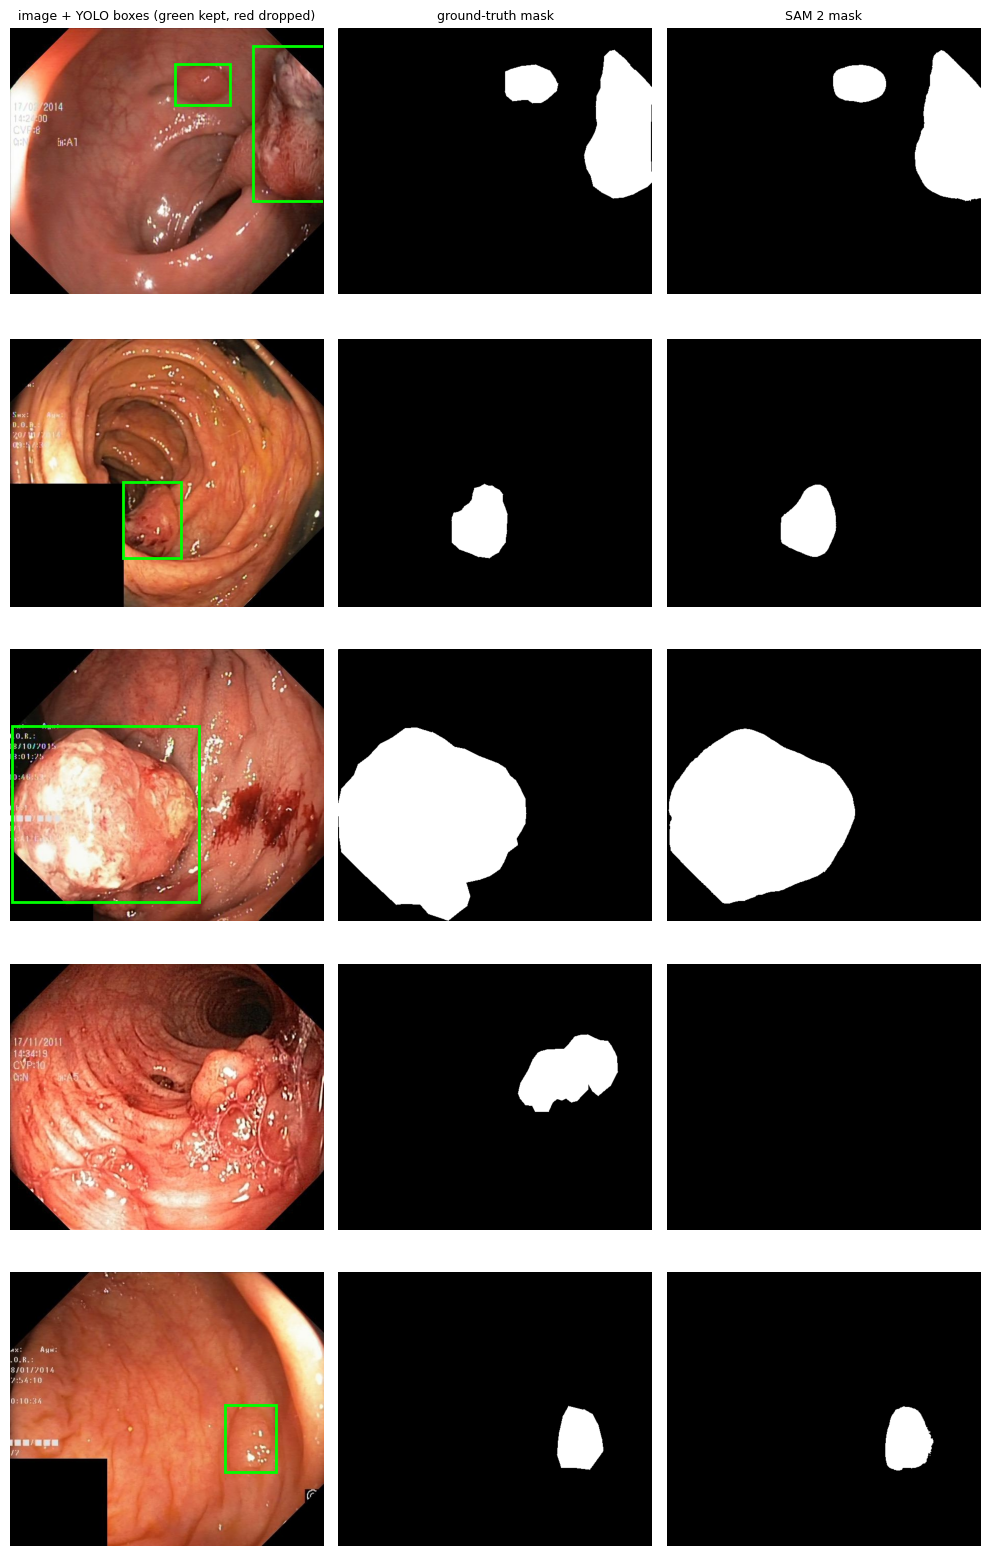

In [10]:
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

W = Path("/content/drive/MyDrive/F26-13/weights")
yolo = YOLO("external/YOLO_SAM2/YOLO_Checkpoints/Kvasir_yolov8m.pt")   # SMOKE TEST ONLY (DL-17)
sam = SAM2ImagePredictor(build_sam2("configs/sam2/sam2_hiera_l.yaml", str(W / "sam2_hiera_large.pt"), device="cuda"))

ids = Path("splits/kvasir_test.txt").read_text().split()[:5]
fig, axes = plt.subplots(5, 3, figsize=(10, 16))
for row, image_id in enumerate(ids):
    img_path = f"data/processed/kvasir/images/test/{image_id}.jpg"
    rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    gt = cv2.imread(f"data/processed/kvasir/masks/test/{image_id}.png", 0) > 127

    det = yolo.predict(img_path, imgsz=640, conf=0.05, verbose=False)[0]
    boxes_xyxy, confs = det.boxes.xyxy.cpu().numpy(), det.boxes.conf.cpu().numpy()

    sam.set_image(rgb)
    pred = np.zeros(gt.shape, bool)
    print(f"\n{image_id}")
    for b, c in zip(boxes_xyxy, confs):
        kept = c >= 0.5
        print(f"  box={np.round(b).astype(int).tolist()}  conf={c:.3f}  {'KEPT' if kept else 'dropped by baseline'}")
        if kept:
            m, _, _ = sam.predict(box=b, multimask_output=False)
            pred |= m[0] > 0
    dice = 2 * (pred & gt).sum() / (pred.sum() + gt.sum() + 1e-8)
    print(f"  Dice = {dice:.3f}")

    axes[row, 0].imshow(rgb)
    for b, c in zip(boxes_xyxy, confs):
        axes[row, 0].add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, lw=2,
                                             color="lime" if c >= .5 else "red"))
    axes[row, 1].imshow(gt, cmap="gray"); axes[row, 2].imshow(pred, cmap="gray")
for ax, t in zip(axes[0], ["image + YOLO boxes (green kept, red dropped)", "ground-truth mask", "SAM 2 mask"]):
    ax.set_title(t, fontsize=9)
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.savefig("smoke_test.png", dpi=100); plt.show()

## 6. Image-shift test set (task 3.6)

Blur, brightness/contrast and Gaussian noise at three strengths, applied to the 200 **test** images only (decision DL-20).

In [11]:
!python src/data/make_corruptions.py

blur_s1                  200 images  {'sigma': 1.0}
blur_s2                  200 images  {'sigma': 2.0}
blur_s3                  200 images  {'sigma': 4.0}
brightness_contrast_s1   200 images  {'contrast': 0.8, 'brightness': -20}
brightness_contrast_s2   200 images  {'contrast': 0.6, 'brightness': -40}
brightness_contrast_s3   200 images  {'contrast': 0.4, 'brightness': -60}
noise_s1                 200 images  {'std': 10.0}
noise_s2                 200 images  {'std': 20.0}
noise_s3                 200 images  {'std': 40.0}
Done: 9 settings written to /content/proj/data/processed/kvasir-corrupted


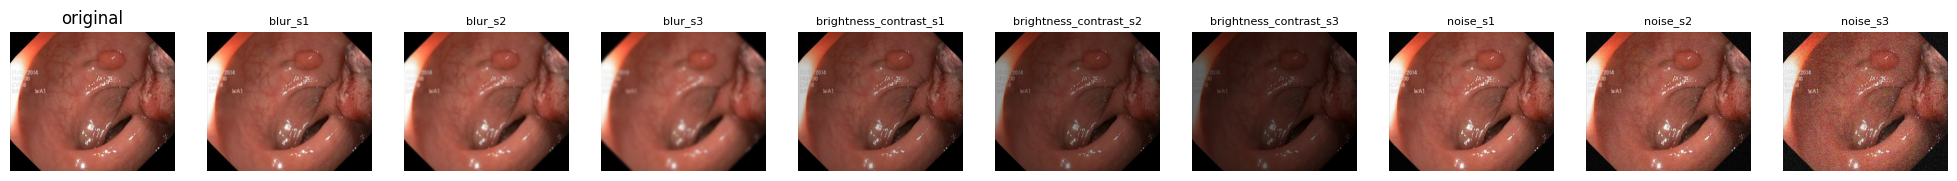

In [12]:
i = ids[0]
settings = sorted(glob.glob("data/processed/kvasir-corrupted/*_s*"))
fig, axes = plt.subplots(1, 10, figsize=(25, 3))
axes[0].imshow(cv2.cvtColor(cv2.imread(f"data/processed/kvasir/images/test/{i}.jpg"), cv2.COLOR_BGR2RGB))
axes[0].set_title("original")
for ax, s in zip(axes[1:], settings):
    ax.imshow(cv2.cvtColor(cv2.imread(f"{s}/images/test/{i}.png"), cv2.COLOR_BGR2RGB))
    ax.set_title(Path(s).name, fontsize=8)
for ax in axes: ax.axis("off")
plt.savefig("corruption_examples.png", dpi=100, bbox_inches="tight"); plt.show()

## 7. Overlay check of the processed data (task 3.5)

20 random test images per dataset (seed 0). Green = mask outline, red = YOLO label box. Every red box should wrap its green outline.

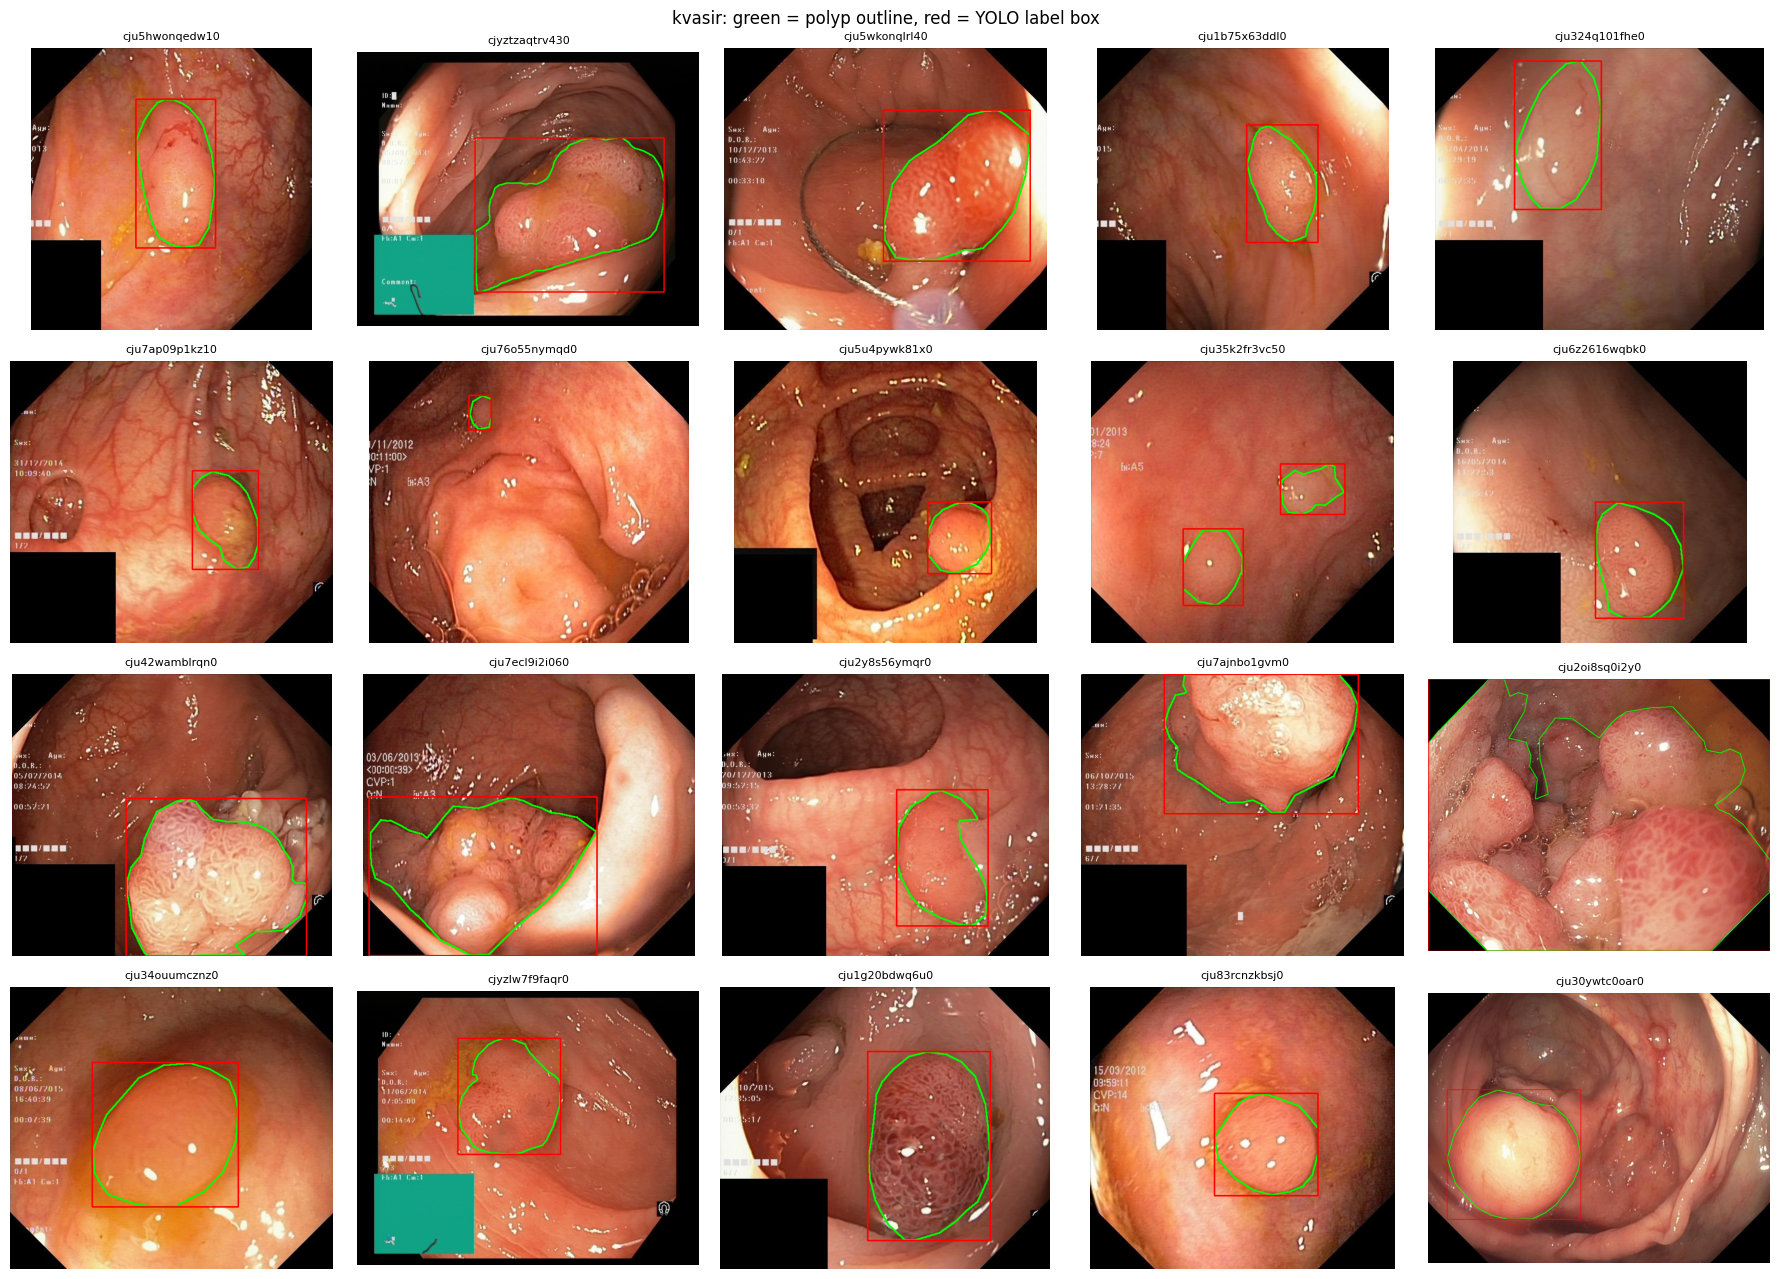

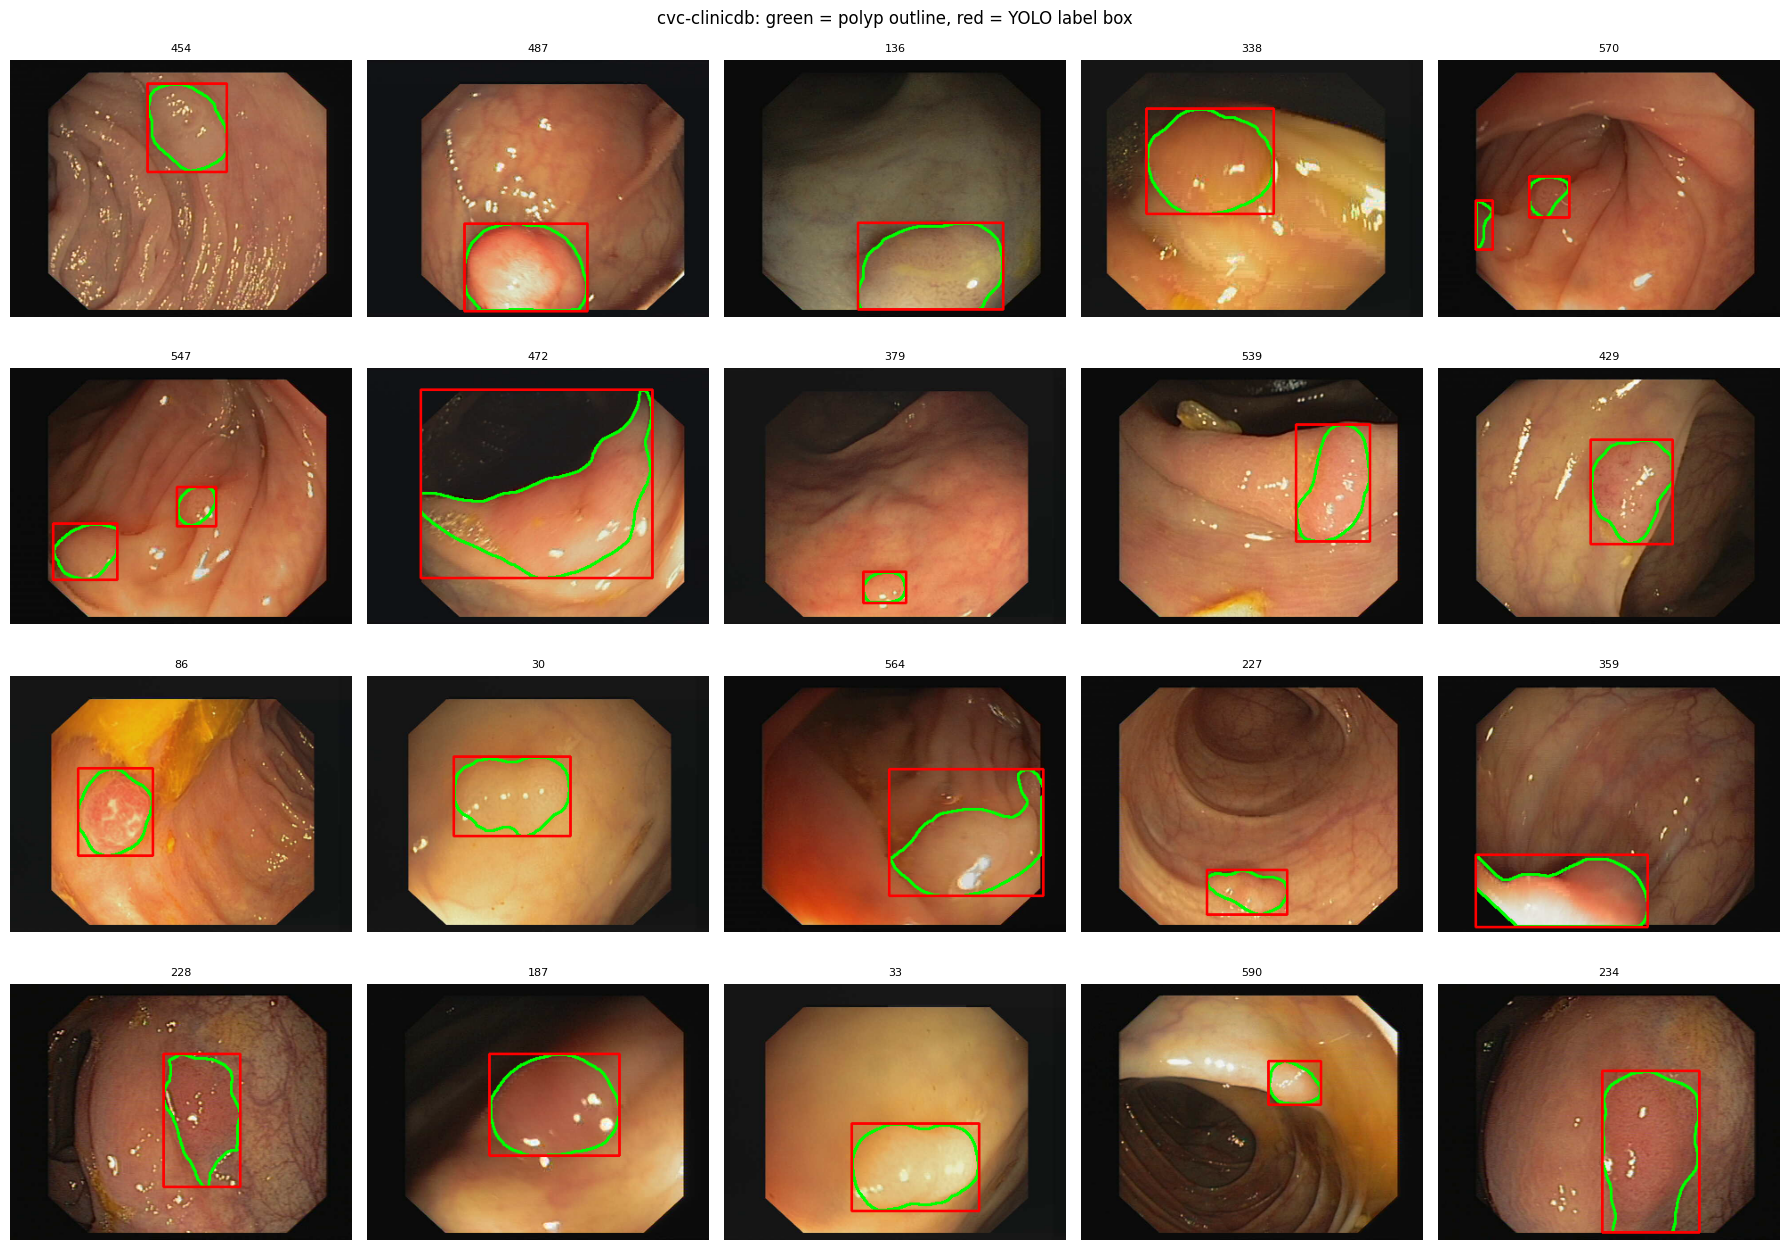

In [13]:
import random
def overlay(dataset, ext, out_name):
    folder = Path(f"data/processed/{dataset}")
    all_ids = sorted(q.stem for q in (folder / "images/test").glob(f"*.{ext}"))
    pick = random.Random(0).sample(all_ids, 20)
    fig, axes = plt.subplots(4, 5, figsize=(18, 13))
    for ax, i in zip(axes.flat, pick):
        rgb = cv2.cvtColor(cv2.imread(str(folder / f"images/test/{i}.{ext}")), cv2.COLOR_BGR2RGB)
        h, w = rgb.shape[:2]
        mask = cv2.imread(str(folder / f"masks/test/{i}.png"), 0) > 127
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        cv2.drawContours(rgb, contours, -1, (0, 255, 0), 2)
        for line in (folder / f"labels/test/{i}.txt").read_text().split("\n"):
            if not line.strip(): continue
            _, xc, yc, bw, bh = map(float, line.split())
            cv2.rectangle(rgb, (int((xc-bw/2)*w), int((yc-bh/2)*h)), (int((xc+bw/2)*w), int((yc+bh/2)*h)), (255, 0, 0), 2)
        ax.imshow(rgb); ax.set_title(i[:14], fontsize=8); ax.axis("off")
    plt.suptitle(f"{dataset}: green = polyp outline, red = YOLO label box"); plt.tight_layout()
    plt.savefig(out_name, dpi=90); plt.show()

overlay("kvasir", "jpg", "overlay_kvasir.png")
overlay("cvc-clinicdb", "png", "overlay_clinicdb.png")

## 8. Save figures to Drive

In [14]:
!mkdir -p /content/drive/MyDrive/F26-13/figures
!cp smoke_test.png corruption_examples.png overlay_kvasir.png overlay_clinicdb.png /content/drive/MyDrive/F26-13/figures/
!ls -la /content/drive/MyDrive/F26-13/figures

total 4696
drwx------ 2 root root    4096 Oct  9 18:32 .
drwx------ 4 root root    4096 Oct  9 18:32 ..
-rw------- 1 root root  409444 Oct  9 18:32 corruption_examples.png
-rw------- 1 root root 1443901 Oct  9 18:32 overlay_clinicdb.png
-rw------- 1 root root 2210812 Oct  9 18:32 overlay_kvasir.png
-rw------- 1 root root  734844 Oct  9 18:32 smoke_test.png


### Follow-up: one Kvasir overlay checked at full size

In the Kvasir grid, row 3 picture 5 showed no visible outline or box at thumbnail size. This cell shows it full size: the polyp covers most of the frame, so the outline and box run along the black border and the label is correct.

Image: cju2oi8sq0i2y0801mektzvw8
Label file: 0 0.500742 0.500000 0.998516 1.000000

Polyp covers 76.3% of the image


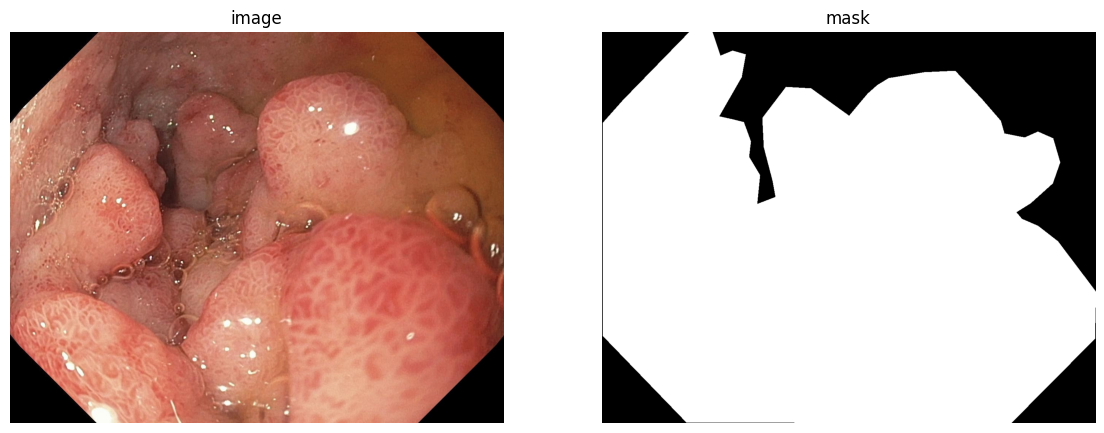

In [15]:
folder = Path("data/processed/kvasir")
all_ids = sorted(q.stem for q in (folder / "images/test").glob("*.jpg"))
i = random.Random(0).sample(all_ids, 20)[14]          # row 3, picture 5
print("Image:", i)
print("Label file:", open(folder / f"labels/test/{i}.txt").read())
mask = cv2.imread(str(folder / f"masks/test/{i}.png"), 0) > 127
print(f"Polyp covers {mask.mean()*100:.1f}% of the image")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rgb = cv2.cvtColor(cv2.imread(str(folder / f"images/test/{i}.jpg")), cv2.COLOR_BGR2RGB)
axes[0].imshow(rgb); axes[0].set_title("image")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("mask")
for ax in axes: ax.axis("off")
plt.show()